In [7]:
%matplotlib widget

from matplotlib import pyplot as plt
from matplotlib import animation
import numpy as np
from scipy import integrate
import matplotlib.animation as animation
from functools import partial
import control as ct
import ipywidgets as widgets

In [8]:
ThermalModelTransferFunction = ct.tf([25], [35.0, 1])

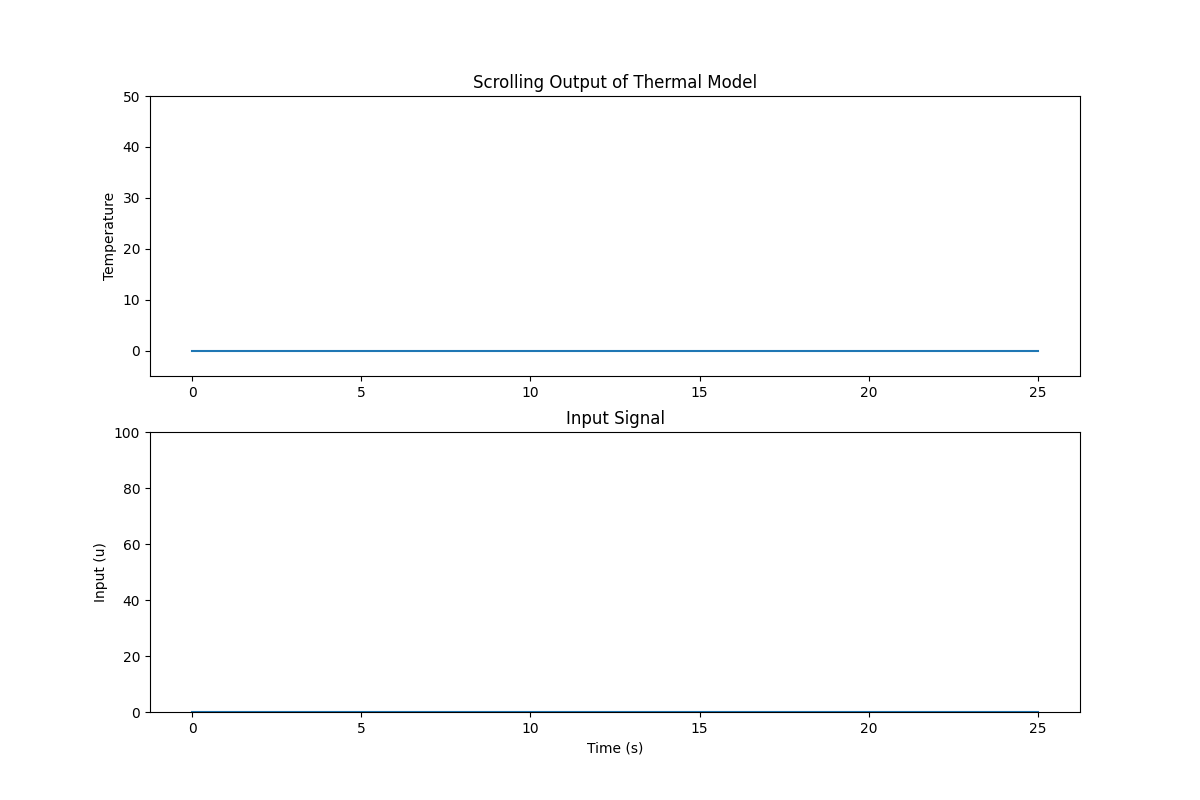

In [9]:
ani = None
window_length = 5     # seconds
dt = 0.1              # seconds
T_amb = 22            # Ambient temperature
  
class Past_inputs_anim:
    """
    Animates the output of a dynamic model over a moving time window.
    Uses solve_ivp for full model flexibility.
    """

    def __init__(self, line, ax, line_input, ax_input, model_function, window_length=10, dt=0.1, T_amb = T_amb, input_function=None):

        self.line = line
        self.ax = ax
        self.line_input = line_input
        self.ax_input = ax_input
        self.model_function = model_function

        self.dt = dt
        self.window_samples = int(window_length / dt)
        self.N = self.window_samples

        self.history = np.ones(self.N)*T_amb
        self.input_history = np.zeros(self.N)
        self.ptr = 0

        self.state = np.array([0])  # Initial temperature
        self.current_time = 0.0

        self.T_amb = T_amb
        self.input_function = input_function if input_function else self.default_input_function

        
    def default_input_function(self, t):
        u = 10*np.heaviside(t-5, 10)
        return u
    
    def init_plot(self):
        self.line.set_ydata(np.zeros(self.N))
        self.line_input.set_ydata(np.zeros(self.N))
        return self.line, self.line_input

    def update_history(self, u):
        # Update history vector, self.step advances the states and the rest of the function write this to the appropriate arrays
        output = self.step()

        # Update pointer and shift buffer
        self.history[self.ptr] = output + self.T_amb
        self.input_history[self.ptr] = u
        self.ptr = (self.ptr + 1) % self.N

        # Chronological order reconstruction
        y_full = np.concatenate(
            (self.history[self.ptr:], self.history[:self.ptr])
        )
        u_full = np.concatenate(
            (self.input_history[self.ptr:], self.input_history[:self.ptr])
        )

        return y_full, u_full

    def step(self):
        """
        Advances system by one dt using forced_response.
        Keeps implementation fully general.
        """
        time_solve = np.linspace(self.current_time, self.current_time+self.dt, 2) #solve as small step between start- and end point
        inputs_solve = self.input_function(time_solve)
        t_out, sol = ct.forced_response(self.model_function, time_solve, inputs_solve, self.state[-1])

        self.current_time += self.dt
        self.state = sol            # works for multi-state systems

        return self.state[-1]                 # assuming 1 state for plotting

    
    def animate(self, i):

        # Example time-varying input
        u = self.input_function(self.current_time)

        y_window, u_window = self.update_history(u)

        x_window = np.linspace(
            self.current_time - len(y_window)*self.dt,
            self.current_time,
            len(y_window)
        )

        self.line.set_data(x_window, y_window)
        self.line_input.set_data(x_window, u_window)
        self.ax.set_xlim(x_window[0], x_window[-1])
        self.ax_input.set_xlim(x_window[0], x_window[-1])

        return self.line, self.line_input


def run_animation(model_function, window_length=25, dt=0.1):

    global ani

    if ani is not None:
        ani.event_source.stop()

    plt.close("all")

    fig, (ax, ax_input) = plt.subplots(2, 1, figsize=(12, 8))

    line, = ax.plot(
        np.linspace(0, window_length, int(window_length/dt)),
        np.zeros(int(window_length/dt))
    )
    
    line_input, = ax_input.plot(
        np.linspace(0, window_length, int(window_length/dt)),
        np.zeros(int(window_length/dt))
    )

    ax.set_ylim(-5, 50)
    ax.set_title("Scrolling Output of Thermal Model")
    # ax.set_xlabel("Time (s)")
    ax.set_ylabel("Temperature")
    
    ax_input.set_ylim(0, 100)
    ax_input.set_title("Input Signal")
    ax_input.set_xlabel("Time (s)")
    ax_input.set_ylabel("Input (u)")

    state = Past_inputs_anim(
        line,
        ax,
        line_input,
        ax_input,
        model_function,
        window_length=window_length,
        dt=dt,
        input_function= lambda t: 100*np.sin(0.1*t)**2
    )

    ani = animation.FuncAnimation(
        fig,
        state.animate,
        init_func=state.init_plot,
        interval=int(dt*1000),
        blit=True,
        save_count=5
    )

    plt.show()

# Run animation
run_animation(ThermalModelTransferFunction)